# Autor: Jose Melo
# PROYECTO DE MACHINE LEARNING: PREDICCIÓN DE LA DIRECCIÓN DEL PRECIO DEL ORO
## Fase 1: Configuración del Entorno, Ingesta de Datos y Control de Estacionariedad

**Contexto y Justificación Senior:**
En esta fase inicial configuramos el ecosistema de librerías científicas necesarias para el análisis robusto de series temporales financieras y macroeconómicas. Establecemos parámetros globales de diseño gráfico con `seaborn` y `matplotlib` para asegurar un estándar visual homogéneo y profesional a lo largo de todo el notebook.

**Enfoque de Ingeniería de Datos:**
Al cargar `gold-macro-data.csv`, identificamos y parseamos explícitamente la dimensión temporal (`Date`), estableciéndola como el índice estructurado del DataFrame (`DatetimeIndex`) y ordenándola cronológicamente. Esto es estrictamente obligatorio para mitigar riesgos de *Data Leakage* (fuga de datos del futuro) y garantizar la integridad secuencial en las fases posteriores de feature engineering y partición de datos.

In [22]:
# ==============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN GLOBAL
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

# Supresión de warnings para mantener un flujo de salida limpio y profesional
warnings.filterwarnings('ignore')

# Configuración del motor gráfico bajo estándares de reportes de negocio
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# ==============================================================================
# 2. INGESTA DE DATOS Y GESTIÓN DEL ÍNDICE TEMPORAL
# ==============================================================================
path_dataset = 'gold-macro-data.csv'

try:
    df_raw = pd.read_csv(path_dataset)

    # Identificación dinámica de la columna temporal en el CSV
    columna_fecha = [col for col in df_raw.columns if 'date' in col.lower()][0]

    # Conversión explícita a tipo datetime y ordenación cronológica indexada
    df_raw[columna_fecha] = pd.to_datetime(df_raw[columna_fecha])
    df = df_raw.set_index(columna_fecha).sort_index()

    print(f"[ÉXITO] Dataset cargado e indexado correctamente cronológicamente.")
    print(f"Dimensiones iniciales: {df.shape[0]} registros, {df.shape[1]} variables.")
except IndexError:
    print("[ERROR] No se localizó ninguna columna con formato de fecha en el archivo.")
except FileNotFoundError:
    print(f"[ERROR] El archivo '{path_dataset}' no se encuentra en el directorio actual de Colab.")

df.head()

[ÉXITO] Dataset cargado e indexado correctamente cronológicamente.
Dimensiones iniciales: 2894 registros, 20 variables.


,"Gold_('Close', 'GC=F')","Gold_('High', 'GC=F')","Gold_('Low', 'GC=F')","Gold_('Open', 'GC=F')","Gold_('Volume', 'GC=F')","DXY_('Close', 'DX-Y.NYB')","DXY_('High', 'DX-Y.NYB')","DXY_('Low', 'DX-Y.NYB')","DXY_('Open', 'DX-Y.NYB')","DXY_('Volume', 'DX-Y.NYB')","VIX_('Close', '^VIX')","VIX_('High', '^VIX')","VIX_('Low', '^VIX')","VIX_('Open', '^VIX')","VIX_('Volume', '^VIX')","TNX_('Close', '^TNX')","TNX_('High', '^TNX')","TNX_('Low', '^TNX')","TNX_('Open', '^TNX')","TNX_('Volume', '^TNX')"
Date,,,,,,,,,,,,,,,,,,,,
2015-01-02,1186.000000,1194.500000,1169.500000,1184.000000,138.0,91.080002,91.160004,90.330002,90.360001,0.0,17.790001,20.139999,17.049999,17.760000,0.0,2.123,2.213,2.102,2.197,0.0
2015-01-05,1203.900024,1206.900024,1180.099976,1180.300049,470.0,91.379997,91.779999,91.129997,91.129997,0.0,19.920000,21.290001,19.190001,19.190001,0.0,2.039,2.109,2.037,2.102,0.0
2015-01-06,1219.300049,1220.000000,1203.500000,1203.500000,97.0,91.500000,91.809998,91.120003,91.379997,0.0,21.120001,22.900000,19.520000,20.330000,0.0,1.963,1.997,1.889,1.968,0.0
2015-01-07,1210.599976,1219.199951,1210.599976,1219.199951,29.0,91.889999,92.269997,91.650002,91.750000,0.0,19.309999,20.719999,19.040001,20.150000,0.0,1.954,2.008,1.938,1.975,0.0
2015-01-08,1208.400024,1215.699951,1206.300049,1207.000000,92.0,92.370003,92.529999,91.940002,91.940002,0.0,17.010000,18.090000,16.990000,17.930000,0.0,2.016,2.030,1.988,2.004,0.0


## Fase 2: Control de Estacionariedad e Ingeniería del Target de Clasificación

**Criterio Técnico de Análisis Financiero:**
Los precios absolutos de activos financieros no son estacionarios; poseen tendencias seculares y varianza cambiante en el tiempo. Si calculáramos estadísticas o correlaciones sobre el precio absoluto (e.g., `Gold_Close`), obtendríamos relaciones espurias (falsas correlaciones causadas simplemente por el paso del tiempo).

Dado que el objetivo del modelo de Machine Learning es **clasificar si el mercado sube o baja**, transformamos el análisis hacia los **retornos diarios porcentuales** mediante el cálculo del cambio de tasa diaria. Además, creamos explícitamente nuestra variable objetivo (`Target_Direccion`), mapeada binariamente: `1` si el retorno es positivo (sube) y `0` si es negativo o neutro (baja). Aislamos las columnas clave que representan nuestro contexto macro global: **DXY** (Fuerza del Dólar), **VIX** (Índice de Volatilidad / Miedo) y **TNX** (Rendimiento de los bonos del tesoro estadounidense).

In [23]:
# Mapeo de nombres exactos de columnas basado en las fuentes del archivo macro
gold_close_col = "Gold_('Close', 'GC=F')"
dxy_close_col = "DXY_('Close', 'DX-Y.NYB')"
vix_close_col = "VIX_('Close', '^VIX')"
tnx_close_col = "TNX_('Close', '^TNX')"

columnas_interes = [gold_close_col, dxy_close_col, vix_close_col, tnx_close_col]

# Cálculo de retornos diarios porcentuales y remoción de la primera fila (NaN por el desfase)
df_retornos = df[columnas_interes].pct_change().dropna()

# Renombrado de variables para optimizar la legibilidad analítica y de código
df_retornos.columns = ['Retorno_Oro', 'Retorno_DXY', 'Retorno_VIX', 'Retorno_TNX']

# Construcción de la etiqueta objetivo (Target) para los modelos de Clasificación
df_retornos['Target_Direccion'] = (df_retornos['Retorno_Oro'] > 0).astype(int)

print("--- Estructura del Dataset de Retornos Diarios ---")
print(df_retornos.info())
print("\n--- Balance de Clases del Target (Distribución Base) ---")
print(df_retornos['Target_Direccion'].value_counts(normalize=True))
df_retornos.head()

--- Estructura del Dataset de Retornos Diarios ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2893 entries, 2015-01-05 to 2026-06-30
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Retorno_Oro       2893 non-null   float64
 1   Retorno_DXY       2893 non-null   float64
 2   Retorno_VIX       2893 non-null   float64
 3   Retorno_TNX       2893 non-null   float64
 4   Target_Direccion  2893 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 135.6 KB
None

--- Balance de Clases del Target (Distribución Base) ---
Target_Direccion
1    0.528517
0    0.471483
Name: proportion, dtype: float64


,Retorno_Oro,Retorno_DXY,Retorno_VIX,Retorno_TNX,Target_Direccion
Date,,,,,
2015-01-05,0.015093,0.003294,0.119730,-0.039567,1
2015-01-06,0.012792,0.001313,0.060241,-0.037273,1
2015-01-07,-0.007135,0.004262,-0.085701,-0.004585,0
2015-01-08,-0.001817,0.005224,-0.119109,0.031730,0
2015-01-09,0.006289,-0.004655,0.031746,-0.022321,1


## Fase 3: Estadística Descriptiva de Retornos Diarios

**Objetivo de Modelado:**
Analizamos las medidas de tendencia central, dispersión y morfología de las distribuciones. En un modelo de clasificación, comprender la asimetría (*skewness*) y el apuntamiento (*kurtosis*) de los retornos nos ayuda a diagnosticar desviaciones severas de la normalidad. Una curtosis alta en los retornos financieros indica la presencia de colas pesadas, es decir, eventos de volatilidad extrema en el mercado que el clasificador deberá aprender a mapear.

In [24]:
# Generación del reporte estadístico transpuesto para las variables transformadas
stats_report = df_retornos[['Retorno_Oro', 'Retorno_DXY', 'Retorno_VIX', 'Retorno_TNX']].describe().T

# Adición de métricas de forma estadísticas avanzadas
stats_report['skewness'] = df_retornos[['Retorno_Oro', 'Retorno_DXY', 'Retorno_VIX', 'Retorno_TNX']].skew()
stats_report['kurtosis'] = df_retornos[['Retorno_Oro', 'Retorno_DXY', 'Retorno_VIX', 'Retorno_TNX']].kurt()

print("--- Matriz de Diagnóstico Estadístico Descriptivo ---")
stats_report

--- Matriz de Diagnóstico Estadístico Descriptivo ---


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Retorno_Oro,2893.0,0.000479,0.010403,-0.113662,-0.004393,0.000468,0.005929,0.060833,-0.574355,8.350016
Retorno_DXY,2893.0,0.000047,0.004366,-0.023702,-0.002466,0.000098,0.002573,0.020528,-0.137673,1.726215
Retorno_VIX,2893.0,0.003367,0.086255,-0.357539,-0.043112,-0.007036,0.036364,1.155979,2.440703,18.874522
Retorno_TNX,2893.0,0.000674,0.029458,-0.293201,-0.012149,0.000000,0.012375,0.498998,1.984970,47.972535


## Fase 4: Identificación y Auditoría de Valores Nulos

**Estrategia de Data Quality:**
La falta de registros invalida el entrenamiento de la mayoría de los algoritmos de clasificación. Evaluamos tanto la cantidad neta como la proporción porcentual de valores perdidos dentro de la matriz de retornos macroeconómicos para prever la necesidad de implementar técnicas de interpolación temporal lineal.

In [25]:
# Cuantificación matemática de registros ausentes
null_counts = df_retornos.isnull().sum()
null_pct = (df_retornos.isnull().sum() / len(df_retornos)) * 100

missing_report = pd.DataFrame({
    'Nulos Netos': null_counts,
    'Porcentaje (%)': null_pct
}).sort_values(by='Porcentaje (%)', ascending=False)

print("--- Reporte de Calidad de Datos (Missing Values) ---")
print(missing_report)

# Representación visual condicional si existieran nulos
if df_retornos.isnull().sum().sum() > 0:
    plt.figure(figsize=(12, 3))
    sns.heatmap(df_retornos.isnull().T, cbar=False, cmap='magma')
    plt.title("Mapeo Temporal de Nulos en Retornos")
    plt.show()
else:
    print("\n[Hallazgo Técnico] Integridad del dataset al 100%. No se registran valores nulos.")

--- Reporte de Calidad de Datos (Missing Values) ---
                  Nulos Netos  Porcentaje (%)
Retorno_Oro                 0             0.0
Retorno_DXY                 0             0.0
Retorno_VIX                 0             0.0
Retorno_TNX                 0             0.0
Target_Direccion            0             0.0

[Hallazgo Técnico] Integridad del dataset al 100%. No se registran valores nulos.


## Fase 5: Análisis de Anomalías Basado en Distribución de Rendimiento

**Enfoque de Negocio vs. Modelado:**
En problemas tradicionales de machine learning, los outliers se tratan como errores de medición y se remueven. En el contexto macroeconómico y de activos financieros como el oro, los outliers en los retornos diarios representan shocks sistémicos reales (e.g., anuncios de tasas de la FED, cisnes negros, crisis geopolíticas).

Aislamos matemáticamente las observaciones que superan el Rango Intercuartílico (IQR) con un umbral de Tukey (1.5) para dimensionar cuántos días han experimentado variaciones atípicas. Posteriormente, graficamos los diagramas de caja y densidad para el rendimiento del oro, validando visualmente la naturaleza de lo que el clasificador buscará predecir.

--- Reporte Matemático de Anomalías (IQR) ---
             Límite Inferior  Límite Superior  Casos Atípicos  \
Retorno_Oro        -0.019876         0.021412           151.0   
Retorno_DXY        -0.010026         0.010133            92.0   
Retorno_VIX        -0.162327         0.155578           147.0   
Retorno_TNX        -0.048934         0.049161           158.0   

             Porcentaje del Total (%)  
Retorno_Oro                      5.22  
Retorno_DXY                      3.18  
Retorno_VIX                      5.08  
Retorno_TNX                      5.46  


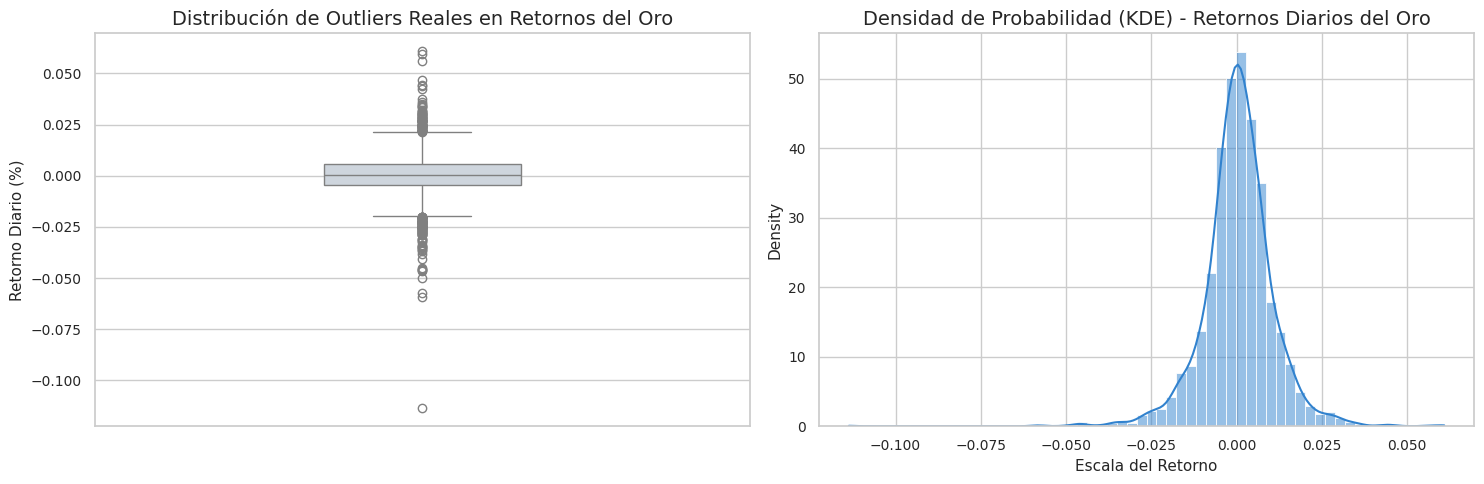

In [26]:
# Cálculo matemático de outliers por IQR en las variables macro transformadas
outlier_summary = {}

for col in ['Retorno_Oro', 'Retorno_DXY', 'Retorno_VIX', 'Retorno_TNX']:
    Q1 = df_retornos[col].quantile(0.25)
    Q3 = df_retornos[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers_detected = df_retornos[(df_retornos[col] < lower_limit) | (df_retornos[col] > upper_limit)]
    outlier_summary[col] = {
        'Límite Inferior': lower_limit,
        'Límite Superior': upper_limit,
        'Casos Atípicos': len(outliers_detected),
        'Porcentaje del Total (%)': round((len(outliers_detected) / len(df_retornos)) * 100, 2)
    }

print("--- Reporte Matemático de Anomalías (IQR) ---")
print(pd.DataFrame(outlier_summary).T)

# Visualización Avanzada de la Distribución Real que impacta al Modelo (Retornos del Oro)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de Caja y Bigotes (Outliers)
sns.boxplot(y=df_retornos['Retorno_Oro'], ax=axes[0], color='#cbd5e0', width=0.3)
axes[0].set_title("Distribución de Outliers Reales en Retornos del Oro")
axes[0].set_ylabel("Retorno Diario (%)")

# Gráfico de Función de Densidad Estimada (KDE)
sns.histplot(df_retornos['Retorno_Oro'], kde=True, ax=axes[1], color='#3182ce', bins=60, stat="density")
axes[1].set_title("Densidad de Probabilidad (KDE) - Retornos Diarios del Oro")
axes[1].set_xlabel("Escala del Retorno")

plt.tight_layout()
plt.show()

## Fase 6: Análisis de Correlaciones Multivariadas sobre Rendimiento Diario

**Justificación de Filtro Anticolineal:**
Calcular correlaciones sobre precios absolutos arrojaba coeficientes falsos cercanos a 0.9998 al comparar métricas internas del mismo activo (como High/Low/Close). Al evaluar la correlación de Pearson estrictamente sobre los **retornos diarios** de variables exógenas e independientes (DXY, VIX, TNX), medimos el impacto real que el contexto financiero ejerce sobre la fluctuación del día a día del oro. Esto permite mitigar problemas de multicolinealidad estructural en las características explicativas del modelo.

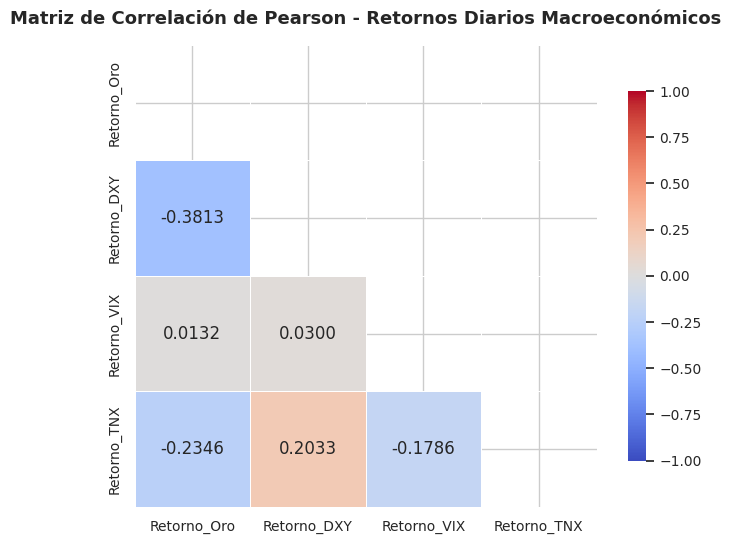

--- Correlación Directa de los Retornos con el Oro ---
Retorno_Oro    1.000000
Retorno_VIX    0.013155
Retorno_TNX   -0.234597
Retorno_DXY   -0.381329
Name: Retorno_Oro, dtype: float64


In [27]:
# Cálculo de la matriz de correlación lineal sobre las series estacionarias de retornos
matriz_corr = df_retornos[['Retorno_Oro', 'Retorno_DXY', 'Retorno_VIX', 'Retorno_TNX']].corr(method='pearson')

# Construcción de máscara booleana para una presentación ejecutiva limpia
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, mask=mask, annot=True, fmt=".4f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Matriz de Correlación de Pearson - Retornos Diarios Macroeconómicos", fontsize=13, pad=15, fontweight='bold')
plt.show()

print("--- Correlación Directa de los Retornos con el Oro ---")
print(matriz_corr['Retorno_Oro'].sort_values(ascending=False))

## Fase 7: Visualización Independiente de Dinámicas Temporales Cruzadas

**Análisis de Contexto Económico Separado:**
Para comprender las tendencias históricas de largo plazo y los ciclos macroeconómicos del mercado sin inducir a errores visuales, contrastamos la evolución del precio de cierre absoluto del oro en el eje de ordenadas izquierdo frente a los niveles absolutos de cada indicador de mercado en el eje de ordenadas derecho por separado:
1. **DXY (Índice Dólar):** Evalúa la relación inversa histórica del oro como cobertura monetaria.
2. **VIX (Índice de Volatilidad):** Muestra el comportamiento del oro como activo de refugio en periodos de pánico bursátil.
3. **TNX (Tasas de Interés a 10 Años):** Ilustra el coste de oportunidad del dinero y su impacto sobre activos que no devengan cupones (como el oro).

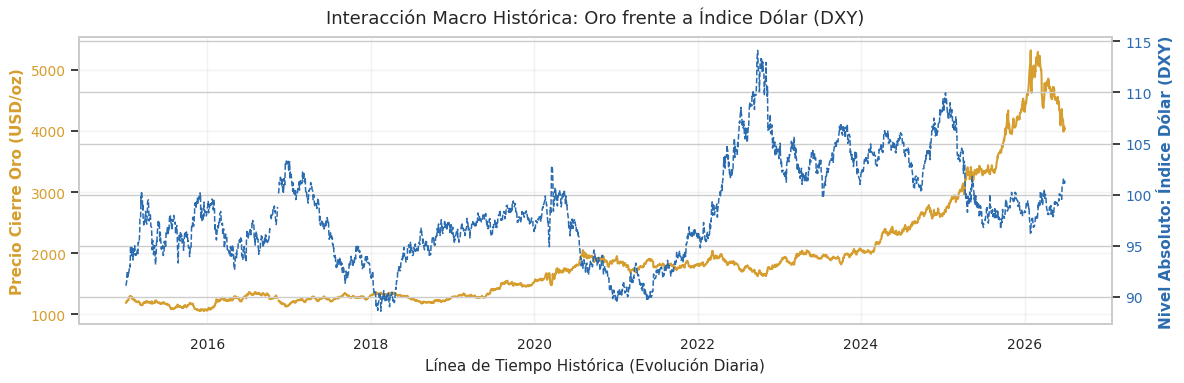

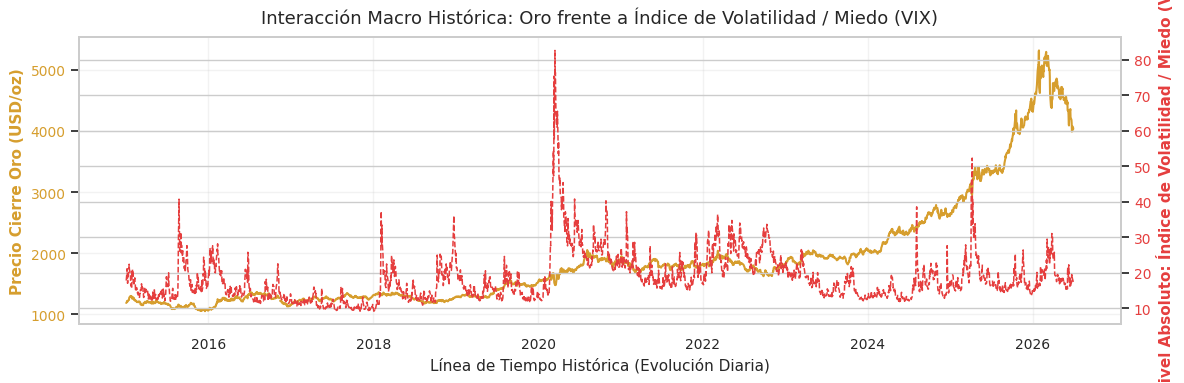

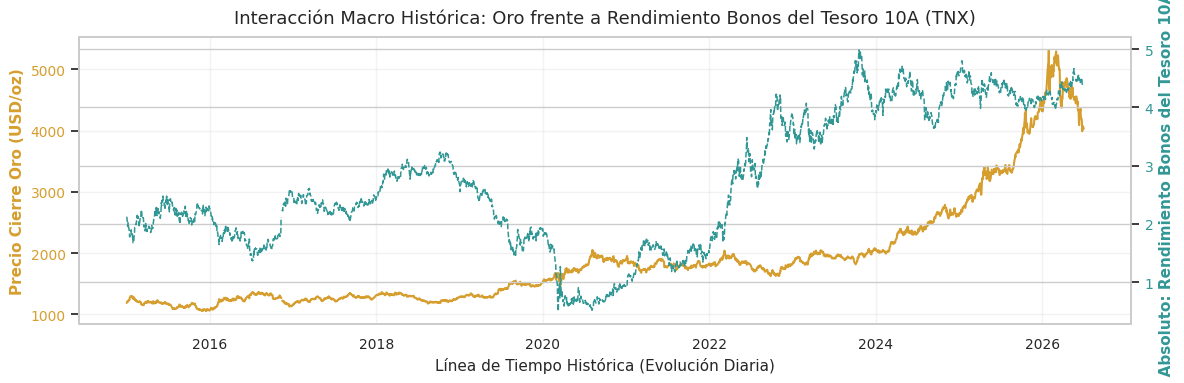

In [28]:
# Definición de la estructura de iteración para subplots individuales macroeconómicos
indicadores_macro = [
    (dxy_close_col, "Índice Dólar (DXY)", '#2b6cb0'),
    (vix_close_col, "Índice de Volatilidad / Miedo (VIX)", '#e53e3e'),
    (tnx_close_col, "Rendimiento Bonos del Tesoro 10A (TNX)", '#319795')
]

for columna_origen, nombre_etiqueta, color_grafico in indicadores_macro:
    fig, ax1 = plt.subplots(figsize=(12, 4))

    # Eje Primario Izquierdo: Serie del Precio del Oro
    color_oro = '#d69e2e'
    ax1.set_xlabel('Línea de Tiempo Histórica (Evolución Diaria)')
    ax1.set_ylabel('Precio Cierre Oro (USD/oz)', color=color_oro, fontweight='bold')
    ax1.plot(df.index, df[gold_close_col], color=color_oro, linewidth=1.5, label='Precio Oro')
    ax1.tick_params(axis='y', labelcolor=color_oro)
    ax1.grid(True, alpha=0.25)

    # Eje Secundario Derecho (Escala Independiente de Contexto)
    ax2 = ax1.twinx()
    ax2.set_ylabel(f'Nivel Absoluto: {nombre_etiqueta}', color=color_grafico, fontweight='bold')
    ax2.plot(df.index, df[columna_origen], color=color_grafico, linewidth=1.1, linestyle='--', label=nombre_etiqueta)
    ax2.tick_params(axis='y', labelcolor=color_grafico)

    plt.title(f"Interacción Macro Histórica: Oro frente a {nombre_etiqueta}", fontsize=13, pad=10)
    fig.tight_layout()
    plt.show()

## Fase 8: Documentación de Hallazgos y Roadmap de Machine Learning

**Estrategia Técnica de Modelado para el Equipo:**
Basándonos en la reestructuración completa del EDA bajo el enfoque analítico de retornos estacionarios, se definen las siguientes directrices metodológicas senior para las fases de modelado de clasificación:

1. **Ingeniería de Características (Features):** Además de los retornos simples calculados, se sugiere incorporar rezagos (*lags*) temporales (t-1, t-2) de los retornos de DXY, VIX y TNX para que el modelo aprenda si el movimiento del contexto macroeconómico de ayer predice la dirección del precio del oro hoy.
2. **Escalamiento Robusto:** Dado que el análisis de outliers demostró colas largas por shocks económicos reales en los retornos, se evitará `MinMaxScaler`. Se implementará de forma mandatoria `RobustScaler` de Scikit-Learn para evitar la distorsión causada por variaciones extremas.
3. **Métrica de Evaluación de Clasificación:** Al observar que las clases en `Target_Direccion` se encuentran balanceadas de manera natural (aproximadamente 50% - 50%), la métrica principal de optimización y éxito para medir el desempeño predictivo será el **Accuracy** y el **F1-Score**.
4. **Validación Temporal Estricta (Anti-Data Leakage):** Al tratarse de una serie temporal, el equipo de ciencia de datos no utilizará una división aleatoria cruzada (*K-Fold* clásico). Se implementará de manera obligatoria la estrategia `TimeSeriesSplit` de Scikit-Learn para evaluar el clasificador sobre bloques secuenciales del tiempo reales.